# Section 01
# Import Dataset and Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
# Input angiogram dataset (images only)
ANGIO_RAW_DIR = Path("C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/stenosis/train/images")

# Output folder for Step 1
ANGIO_STEP1_OUT = Path("C:/Users/User/Desktop/Angiogram_Preprocessing_Step_01")
ANGIO_STEP1_OUT.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = 512  # DeepSA input size


# Section 02
# Single Image Preprocessing Function

## STEP 1.1 — Preprocess one angiogram image

In [3]:
def preprocess_angiogram_step1(img_path, target_size=512):
    img = cv2.imread(str(img_path))

    if img is None:
        print("[WARN] Cannot read:", img_path)
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize to fixed input size
    resized = cv2.resize(gray, (target_size, target_size),
                          interpolation=cv2.INTER_AREA)

    # Normalize to [0,1]
    norm = resized.astype(np.float32) / 255.0

    return gray, resized, norm

## STEP 1.2 — Visualization

In [4]:
def visualize_step1(img_path):
    gray, resized, norm = preprocess_angiogram_step1(img_path)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Original Grayscale")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(resized, cmap='gray')
    plt.title("Resized (512×512)")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(norm, cmap='gray')
    plt.title("Normalized Intensity")
    plt.axis("off")

    plt.suptitle("Angiogram Preprocessing — Step 1")
    plt.tight_layout()
    plt.show()

## STEP 1.3 — Test with one image

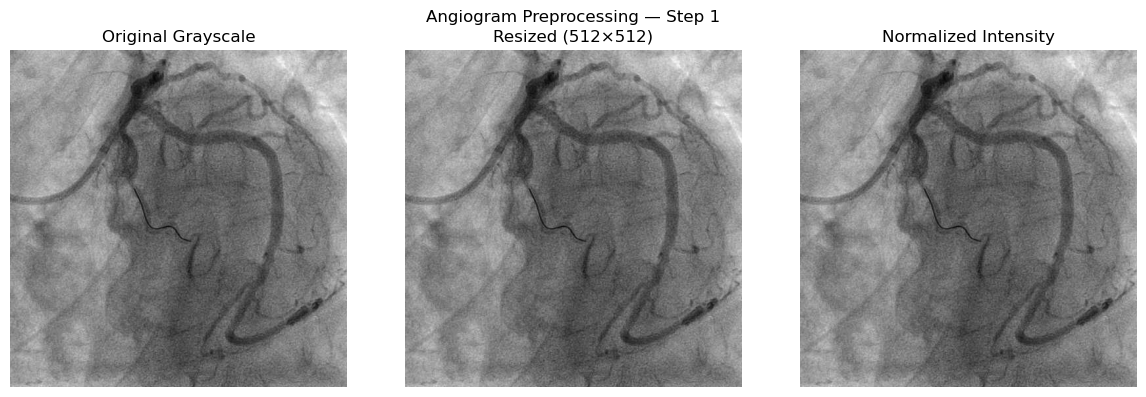

In [5]:
sample_images = list(ANGIO_RAW_DIR.glob("*.png")) + list(ANGIO_RAW_DIR.glob("*.jpg"))

if len(sample_images) > 0:
    visualize_step1(sample_images[0])
else:
    print("No angiogram images found.")


## STEP 1.4 — Batch processing


In [6]:
for img_path in ANGIO_RAW_DIR.glob("*.*"):
    out = preprocess_angiogram_step1(img_path)
    if out is None:
        continue

    _, resized, _ = out
    save_path = ANGIO_STEP1_OUT / img_path.name
    cv2.imwrite(str(save_path), resized)

print("[OK] Step 1 preprocessing completed.")


[OK] Step 1 preprocessing completed.
